# Análisis de resultados de experimentos computacionales

In [ ]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12
plt.rcParams['savefig.dpi'] = 300

---

### Lectura, Extracción y Almacenamiento de resultados

In [26]:
RESULTS_DIR = "../Results"
ALGORITMOS = ["CLASSIC", "QLEARNING"]
RUTA_TIEMPOS = os.path.join(RESULTS_DIR, "tiempos_ejecucion_limpios.csv")
CACHE_FILE = "df_master_cache.csv"

if os.path.exists(CACHE_FILE):
    print(f"Caché encontrado. Cargando datos directamente desde '{CACHE_FILE}'...")
    df_master = pd.read_csv(CACHE_FILE)
    print(f"Total de filas cargadas: {len(df_master)}")

else:
    print("No hay caché. Iniciando la lectura masiva optimizada...")
    datos_experimentos = []
    
    for algo in ALGORITMOS:
        path_busqueda = os.path.join(RESULTS_DIR, algo, "metrics", "*.csv")
        archivos_csv = glob.glob(path_busqueda)
        
        for ruta_archivo in archivos_csv:
            nombre_archivo = os.path.basename(ruta_archivo)
            partes = nombre_archivo.replace(".csv", "").split("_")
            
            if len(partes) >= 4:
                instancia = partes[1]
                run_id = partes[3].replace("run", "")
                
                try:
                    with open(ruta_archivo, 'r') as f:
                        contenido = f.read()
                    
                    historial_str = contenido.split('# MATRIZ_Q_DESTRUCCION')[0]
                            
                    df_run = pd.read_csv(io.StringIO(historial_str))
                    
                    if not df_run.empty:
                        ultima_fila = df_run.iloc[-1]
                        final_veh = ultima_fila['best_veh']
                        final_dist = ultima_fila['best_dist']
                        
                        idx_convergencia = df_run[(df_run['best_veh'] == final_veh) & 
                                                  (df_run['best_dist'] == final_dist)].index[0]
                        
                        iter_optimo = df_run.loc[idx_convergencia, 'iter']
                        
                        datos_experimentos.append({
                            "Algoritmo": algo,
                            "Instancia": instancia.lower(),
                            "Run": int(run_id),
                            "Vehiculos": final_veh,      
                            "Distancia": final_dist,     
                            "Iter_Convergencia": iter_optimo
                        })
                except Exception as e:
                    print(f"[ERROR] En {nombre_archivo}: {e}")

    df_master = pd.DataFrame(datos_experimentos)
    print(f"Extracción completada: {len(df_master)} corridas procesadas.")

    try:
        df_tiempos = pd.read_csv(RUTA_TIEMPOS)
        df_tiempos['Instancia'] = df_tiempos['Instancia'].astype(str).str.lower().str.strip()
        
        df_master = pd.merge(df_master, df_tiempos, on=['Instancia', 'Algoritmo', 'Run'], how='inner')
        print("=== INTEGRACIÓN DE TIEMPOS COMPLETADA ===")
        print(f"Total de filas consolidadas: {len(df_master)}")

        df_master.to_csv(CACHE_FILE, index=False)
        print(f"Datos guardados exitosamente en '{CACHE_FILE}'. La próxima ejecución será instantánea.")
        
    except FileNotFoundError:
        print(f"[ERROR] No se encontró el archivo en: {RUTA_TIEMPOS}")

df_master.head()

Caché encontrado. Cargando datos directamente desde 'df_master_cache.csv'...
Total de filas cargadas: 1120


,Algoritmo,Instancia,Run,Vehiculos,Distancia,Iter_Convergencia,Tiempo_s
0,CLASSIC,c101,1,10.0,828.937,16,4.3929
1,CLASSIC,c101,10,10.0,828.937,7,4.3496
2,CLASSIC,c101,2,10.0,828.937,58,4.4322
3,CLASSIC,c101,3,10.0,828.937,50,4.4281
4,CLASSIC,c101,4,10.0,828.937,57,4.3851


---

### GAP de resultados vs BKS del SINTEF

In [24]:
def consolidar_instancia(g):
    best_veh = g['Vehiculos'].min()
    good_runs = g[g['Vehiculos'] == best_veh]
    best_dist = good_runs['Distancia'].min()
    avg_veh = g['Vehiculos'].mean()
    avg_dist = good_runs['Distancia'].mean()

    return pd.Series({
        'Best_Veh': best_veh,
        'Best_Dist': best_dist,
        'Avg_Veh': avg_veh,
        'Avg_Dist': avg_dist,
        'Avg_Time': g['Tiempo_s'].mean(),
        'BKS_Veh': g['BKS_Veh'].iloc[0],
        'BKS_Dist': g['BKS_Dist'].iloc[0]
    })

def calcular_metricas_familia(g):
    exito_mask = g['Best_Veh'] <= g['BKS_Veh'] 
    tasa_exito = exito_mask.mean() * 100
    
    gap_f1 = ((g['Best_Veh'] - g['BKS_Veh']) / g['BKS_Veh'] * 100).mean()
    
    g_exito = g[exito_mask]
    if not g_exito.empty:
        gap_f2_raw = ((g_exito['Best_Dist'] - g_exito['BKS_Dist']) / g_exito['BKS_Dist']) * 100
        gap_f2 = gap_f2_raw.clip(lower=0).mean()
    else:
        gap_f2 = np.nan
        
    gap_avg_f1 = ((g['Avg_Veh'] - g['BKS_Veh']) / g['BKS_Veh'] * 100).mean()
    if not g_exito.empty:
        gap_avg_f2_raw = ((g_exito['Avg_Dist'] - g_exito['BKS_Dist']) / g_exito['BKS_Dist']) * 100
        gap_avg_f2 = gap_avg_f2_raw.clip(lower=0).mean()
    else:
        gap_avg_f2 = np.nan

    tiempo_cpu = g['Avg_Time'].mean()
    
    return pd.Series({
        'Tasa Éxito f_1 (%)': tasa_exito,
        'GAP Best f_1 (%)': gap_f1,
        'GAP Best f_2 Cond. (%)': gap_f2,
        
        'GAP Avg f_1 (%)': gap_avg_f1,
        'GAP Avg f_2 Cond. (%)': gap_avg_f2,
        'Tiempo CPU (s)': tiempo_cpu
    })

In [25]:
df_master['Familia'] = df_master['Instancia'].str.upper().apply(
    lambda x: x[:3] if x.startswith('RC') else x[:2]
)

RUTA_SINTEF = "sintef.csv"
try:
    df_sintef = pd.read_csv(RUTA_SINTEF, sep=';')
    df_sintef = df_sintef.rename(columns={
        'Vehículos': 'BKS_Veh',
        'Distancia': 'BKS_Dist'
	})
    df_sintef['Instancia'] = df_sintef['Instancia'].astype(str).str.lower().str.strip()
    df_eval = pd.merge(df_master, df_sintef, on='Instancia', how='left')
except FileNotFoundError:
    print(f"[ERROR] No se encontró el archivo de BKS en: {RUTA_SINTEF}")
    raise

df_instancias = df_eval.groupby(['Familia', 'Instancia', 'Algoritmo']).apply(consolidar_instancia).reset_index()
tabla_cruda = df_instancias.groupby(['Familia', 'Algoritmo']).apply(calcular_metricas_familia).reset_index()

# GAP SINTEF vs Mejores runs
cols_t1 = ['Familia', 'Algoritmo', 'Tasa Éxito f_1 (%)', 'GAP Best f_1 (%)', 'GAP Best f_2 Cond. (%)']
tabla_1 = tabla_cruda[cols_t1].pivot(index='Familia', columns='Algoritmo').round(2)

# Robustez (Run promedio)
cols_t2 = ['Familia', 'Algoritmo', 'GAP Avg f_1 (%)', 'GAP Avg f_2 Cond. (%)', 'Tiempo CPU (s)']
tabla_2 = tabla_cruda[cols_t2].pivot(index='Familia', columns='Algoritmo').round(2)

print("="*50)
print("TABLA 1: RENDIMIENTO MÁXIMO (BEST RUNS VS SINTEF)")
print("="*50)
display(tabla_1)

print("\n" + "="*50)
print("TABLA 2: ESTABILIDAD Y ROBUSTEZ (AVERAGE RUNS)")
print("="*50)
display(tabla_2)

TABLA 1: RENDIMIENTO MÁXIMO (BEST RUNS VS SINTEF)


Tasa Éxito f_1 (%)           GAP Best f_1 (%)            \
Algoritmo            CLASSIC QLEARNING          CLASSIC QLEARNING   
Familia                                                             
C1                    100.00    100.00             0.00      0.00   
C2                    100.00    100.00             0.00      0.00   
R1                     50.00     50.00             5.11      5.11   
R2                     63.64     63.64            16.67     16.67   
RC1                    50.00     62.50             4.03      3.14   
RC2                    87.50     87.50             4.17      4.17   

          GAP Best f_2 Cond. (%)            
Algoritmo                CLASSIC QLEARNING  
Familia                                     
C1                          0.00      0.00  
C2                          0.00      0.00  
R1                          0.19      0.40  
R2                          0.33      0.49  
RC1                         0.12      0.12  
RC2                         1.05      0.93


TABLA 2: ESTABILIDAD Y ROBUSTEZ (AVERAGE RUNS)


GAP Avg f_1 (%)           GAP Avg f_2 Cond. (%)            \
Algoritmo         CLASSIC QLEARNING               CLASSIC QLEARNING   
Familia                                                               
C1                   0.00      0.00                  0.00      0.00   
C2                   0.00      0.00                  0.19      0.00   
R1                   6.46      6.39                  0.38      0.68   
R2                  16.67     17.12                  1.92      2.02   
RC1                  5.13      5.48                  1.04      0.90   
RC2                 11.67     10.00                  2.87      3.02   

          Tiempo CPU (s)            
Algoritmo        CLASSIC QLEARNING  
Familia                             
C1                  5.13      5.38  
C2                  4.84      4.25  
R1                  6.44      6.07  
R2                  5.57      4.83  
RC1                 5.99      5.70  
RC2                 5.43      4.81

---

### Distribución del GAP de $f_2$ por familia de instancias

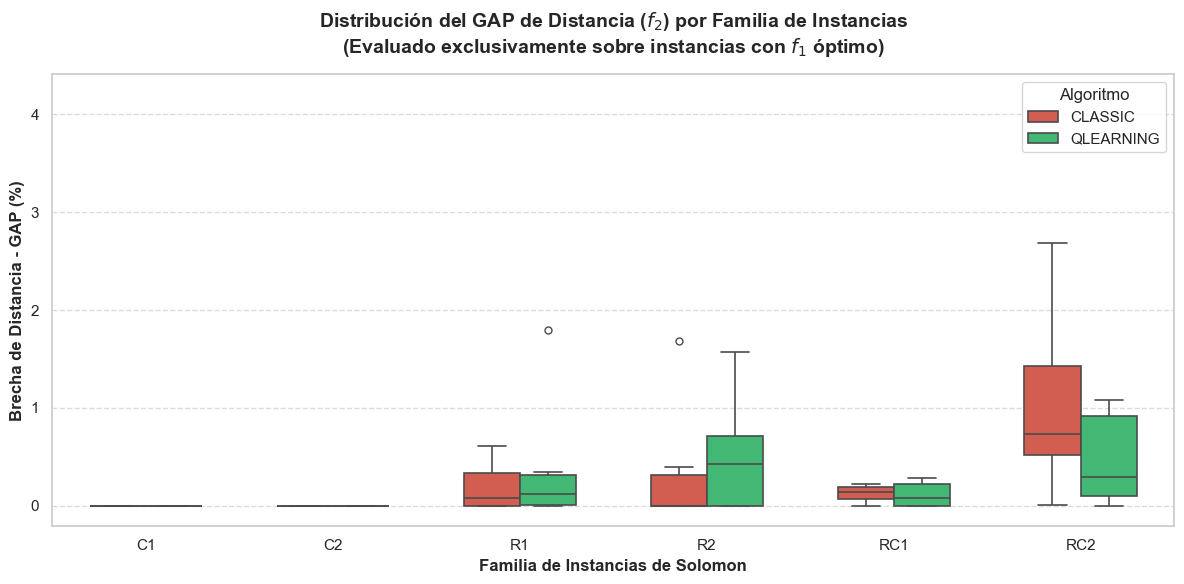

In [38]:
df_plot = df_instancias[df_instancias['Best_Veh'] <= df_instancias['BKS_Veh']].copy()
df_plot['GAP_f2'] = (((df_plot['Best_Dist'] - df_plot['BKS_Dist']) / df_plot['BKS_Dist']) * 100)
df_plot['GAP_f2'] = df_plot['GAP_f2'].clip(lower=0).round(2)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    data=df_plot, 
    x='Familia', 
    y='GAP_f2', 
    hue='Algoritmo',
    palette={'CLASSIC': '#e74c3c', 'QLEARNING': '#2ecc71'}, 
    width=0.6,
    linewidth=1.2,
    fliersize=5
)

plt.title('Distribución del GAP de Distancia ($f_2$) por Familia de Instancias\n(Evaluado exclusivamente sobre instancias con $f_1$ óptimo)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Familia de Instancias de Solomon', fontsize=12, fontweight='bold')
plt.ylabel('Brecha de Distancia - GAP (%)', fontsize=12, fontweight='bold')
plt.legend(title='Algoritmo', title_fontsize='12', fontsize='11', loc='upper right')

ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---

### Marcador Cara a Cara: ALNS vs ALNS-Q

In [40]:
def evaluar_enfrentamiento(row):
    v_c = row['Veh_CLASSIC']
    v_q = row['Veh_QLEARNING']
    d_c = row['Dist_CLASSIC']
    d_q = row['Dist_QLEARNING']
    
    # f_1
    if v_q < v_c:
        return 'Victoria'
    elif v_q > v_c:
        return 'Derrota'
    else:
        # f_2
        if d_q < d_c:
            return 'Victoria'
        elif d_q > d_c:
            return 'Derrota'
        else:
            return 'Empate'

In [41]:
df_wtl = df_instancias.pivot(
    index=['Familia', 'Instancia'], 
    columns='Algoritmo', 
    values=['Best_Veh', 'Best_Dist']
).reset_index()

df_wtl.columns = ['Familia', 'Instancia', 'Veh_CLASSIC', 'Veh_QLEARNING', 'Dist_CLASSIC', 'Dist_QLEARNING']

df_wtl['Dist_CLASSIC'] = df_wtl['Dist_CLASSIC'].round(2)
df_wtl['Dist_QLEARNING'] = df_wtl['Dist_QLEARNING'].round(2)
df_wtl['Resultado_Q'] = df_wtl.apply(evaluar_enfrentamiento, axis=1)

marcador = pd.crosstab(df_wtl['Familia'], df_wtl['Resultado_Q'])

for col in ['Victoria', 'Empate', 'Derrota']:
    if col not in marcador:
        marcador[col] = 0

marcador = marcador[['Victoria', 'Empate', 'Derrota']]

marcador.loc['TOTAL'] = marcador.sum()

print("="*50)
print("MARCADOR FINAL: ALNS-Q vs ALNS Clásico")
print("="*50)
display(marcador)

MARCADOR FINAL: ALNS-Q vs ALNS Clásico


Resultado_Q,Victoria,Empate,Derrota
Familia,,,
C1,0,9,0
C2,0,8,0
R1,3,4,5
R2,4,3,4
RC1,3,3,2
RC2,4,1,3
TOTAL,14,28,14


---

### Trade-off Computacional 

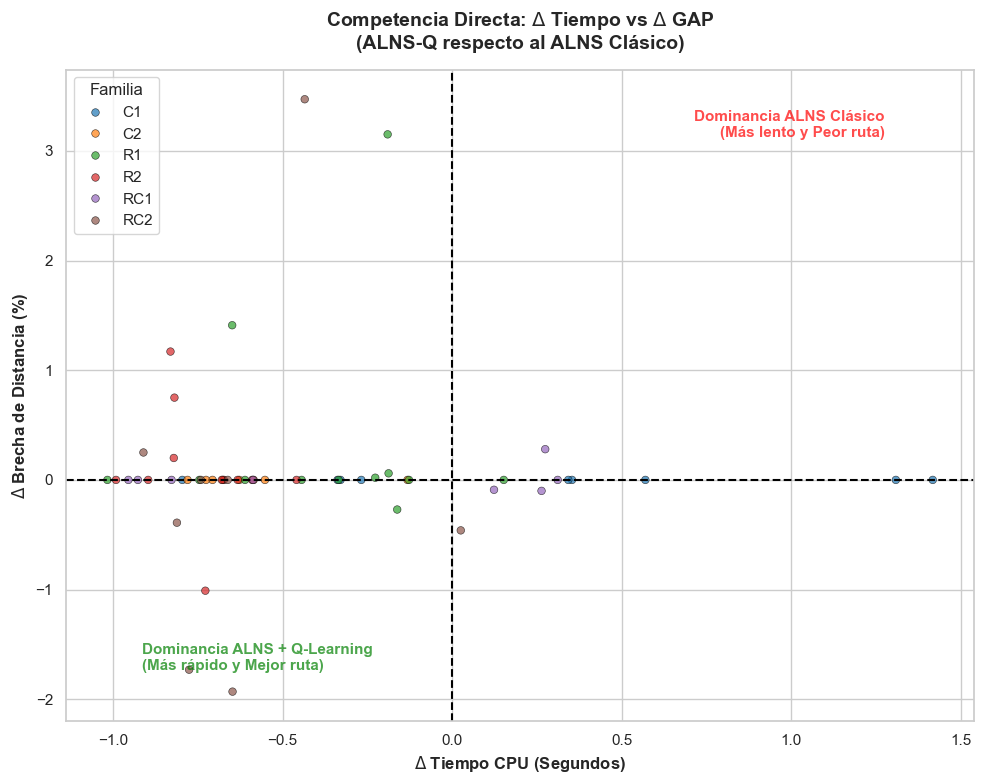

In [46]:
df_delta = df_instancias.pivot(
    index=['Familia', 'Instancia'], 
    columns='Algoritmo', 
    values=['Avg_Time', 'Best_Dist', 'BKS_Dist']
).reset_index()

df_delta.columns = ['Familia', 'Instancia', 
                    'Time_CLASSIC', 'Time_QLEARNING', 
                    'Dist_CLASSIC', 'Dist_QLEARNING',
                    'BKS_Dist_C', 'BKS_Dist_Q']

df_delta['GAP_CLASSIC'] = (((df_delta['Dist_CLASSIC'] - df_delta['BKS_Dist_C']) / df_delta['BKS_Dist_C']) * 100).clip(lower=0).round(2)
df_delta['GAP_QLEARNING'] = (((df_delta['Dist_QLEARNING'] - df_delta['BKS_Dist_Q']) / df_delta['BKS_Dist_Q']) * 100).clip(lower=0).round(2)

df_delta['Delta_Time'] = df_delta['Time_QLEARNING'] - df_delta['Time_CLASSIC']
df_delta['Delta_GAP'] = df_delta['GAP_QLEARNING'] - df_delta['GAP_CLASSIC']

plt.figure(figsize=(10, 8))

ax = sns.scatterplot(
    data=df_delta, 
    x='Delta_Time', 
    y='Delta_GAP', 
    hue='Familia',
    palette='tab10',
    s=30, 
    alpha=0.7,
    edgecolor='black'
)

plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.axvline(0, color='black', linewidth=1.5, linestyle='--')

plt.text(df_delta['Delta_Time'].min() * 0.9, df_delta['Delta_GAP'].min() * 0.9, 
         'Dominancia ALNS + Q-Learning\n(Más rápido y Mejor ruta)', 
         fontsize=11, color='green', fontweight='bold', alpha=0.7, ha='left')

plt.text(df_delta['Delta_Time'].max() * 0.9, df_delta['Delta_GAP'].max() * 0.9, 
         'Dominancia ALNS Clásico\n(Más lento y Peor ruta)', 
         fontsize=11, color='red', fontweight='bold', alpha=0.7, ha='right')

plt.title('Competencia Directa: $\Delta$ Tiempo vs $\Delta$ GAP\n(ALNS-Q respecto al ALNS Clásico)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('$\Delta$ Tiempo CPU (Segundos)', fontsize=12, fontweight='bold')
plt.ylabel('$\Delta$ Brecha de Distancia (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---